# Personal Information
Name: **Maja Kubara**

StudentID: **14498863**

Email: [**maja.kubara@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **22.03.2026**

# Data Context
**In this section you should introduce the datasources and datasets which you will be working with. Explain where they are from as well as their domain. Give an overview of what the context of the data is. You should not spend more than 1 to 2 paragraphs here as the core information will be in the next section.**

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

As you can see, you are in a jupyter notebook environment here. This means that you should focus little on writing text and more on actually exploring your data. If you need to, you can use the amsmath environment in-line: $e=mc^2$ or also in separate equations such as here:

\begin{equation}
    e=mc^2 \mathrm{\space where \space} e,m,c\in \mathbb{R}
\end{equation}

Furthermore, you can insert images such as your data aggregation diagrams like this:

![image](example.png)

In [24]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Loading

In [22]:
import xarray as xr
KNMI = xr.open_dataset("data/KIS___OPER_P___OBS_____L2.nc", decode_cf=True, mask_and_scale=True)
for var in KNMI.data_vars:
    print(f"Variable: {var}")
    print(KNMI[var])
    print("\n")

Variable: DDVEC
<xarray.DataArray 'DDVEC' (station: 49, time: 27458)> Size: 5MB
[1345442 values with dtype=float32]
Coordinates:
  * station  (station) <U3 588B '201' '203' '204' '205' ... '380' '391' '392'
    lat      (station) float64 392B ...
    lon      (station) float64 392B ...
  * time     (time) datetime64[ns] 220kB 1951-01-02 1951-01-03 ... 2026-03-06
Attributes:
    kisid:          DDVEC
    description:    Vector mean wind direction in degrees (360
    standard_name:  wind_from_direction
    units:          degree
    long_name:      Vector average wind direction


Variable: FHVEC
<xarray.DataArray 'FHVEC' (station: 49, time: 27458)> Size: 5MB
[1345442 values with dtype=float32]
Coordinates:
  * station  (station) <U3 588B '201' '203' '204' '205' ... '380' '391' '392'
    lat      (station) float64 392B ...
    lon      (station) float64 392B ...
  * time     (time) datetime64[ns] 220kB 1951-01-02 1951-01-03 ... 2026-03-06
Attributes:
    kisid:          FHVEC
    descript

In [23]:
data = pd.read_parquet("data/air_quality_with_meteorological_data.parquet")
filtered_data = data[data["distance_km"] <= 10]

In [15]:
filtered_data.columns

Index(['Samplingpoint', 'Pollutant', 'Date', 'Value', 'Unit', 'Validity',
       'Verification', 'AQstation_id', 'notation', 'AQstation_lat',
       'AQstation_lon', 'AQStationName', 'distance_km', 'KNMI_station_id',
       'DDVEC', 'FHVEC', 'TG', 'RH', 'UG', 'EV24', 'PG', 'iso_dataset',
       'product', 'projection', 'KNMI_station_lat', 'KNMI_station_lon'],
      dtype='str')

### Analysis 1: Target variable - precipitation
Make sure to add some explanation of what you are doing in your code. This will help you and whoever will read this a lot in following your steps.

C:\Users\majak\AppData\Local\Temp\ipykernel_13408\3779241385.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_13408\3779241385.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_13408\3779241385.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_13408\3779241385.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no a

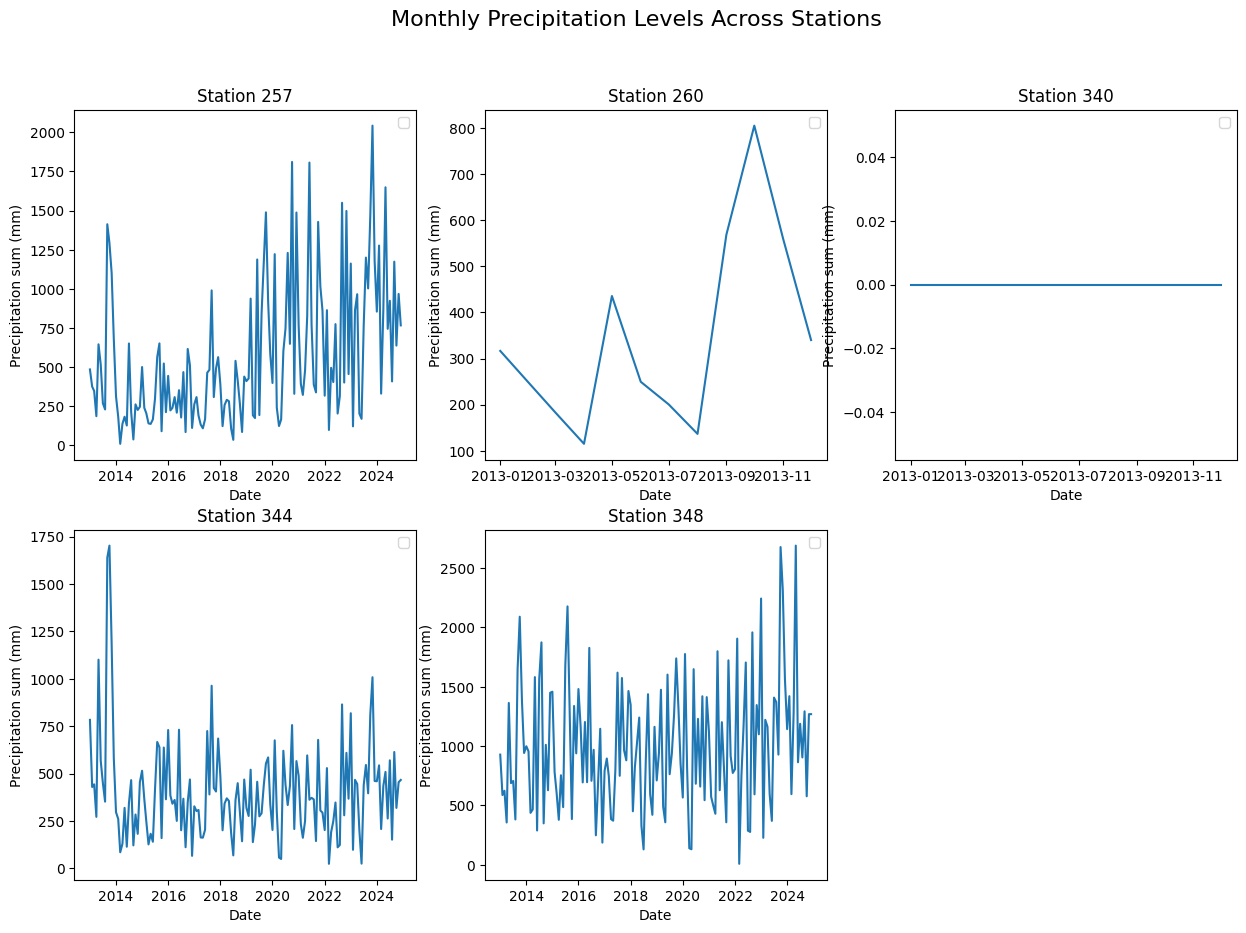

<Figure size 640x480 with 0 Axes>

In [ ]:
# Precipitation levels (RH) overtime across stations
KNMI_stations = list(np.unique(filtered_data["KNMI_station_id"]))

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    monthly = station_data.groupby(station_data["Date"].dt.to_period("M"))["RH"].sum()
    axes[i].plot(monthly.index.to_timestamp(), monthly.values)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Precipitation sum (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Monthly Precipitation Levels (mm) across KNMI Stations", fontsize=16)

plt.show()
plt.tight_layout()

C:\Users\majak\AppData\Local\Temp\ipykernel_13408\2994308808.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


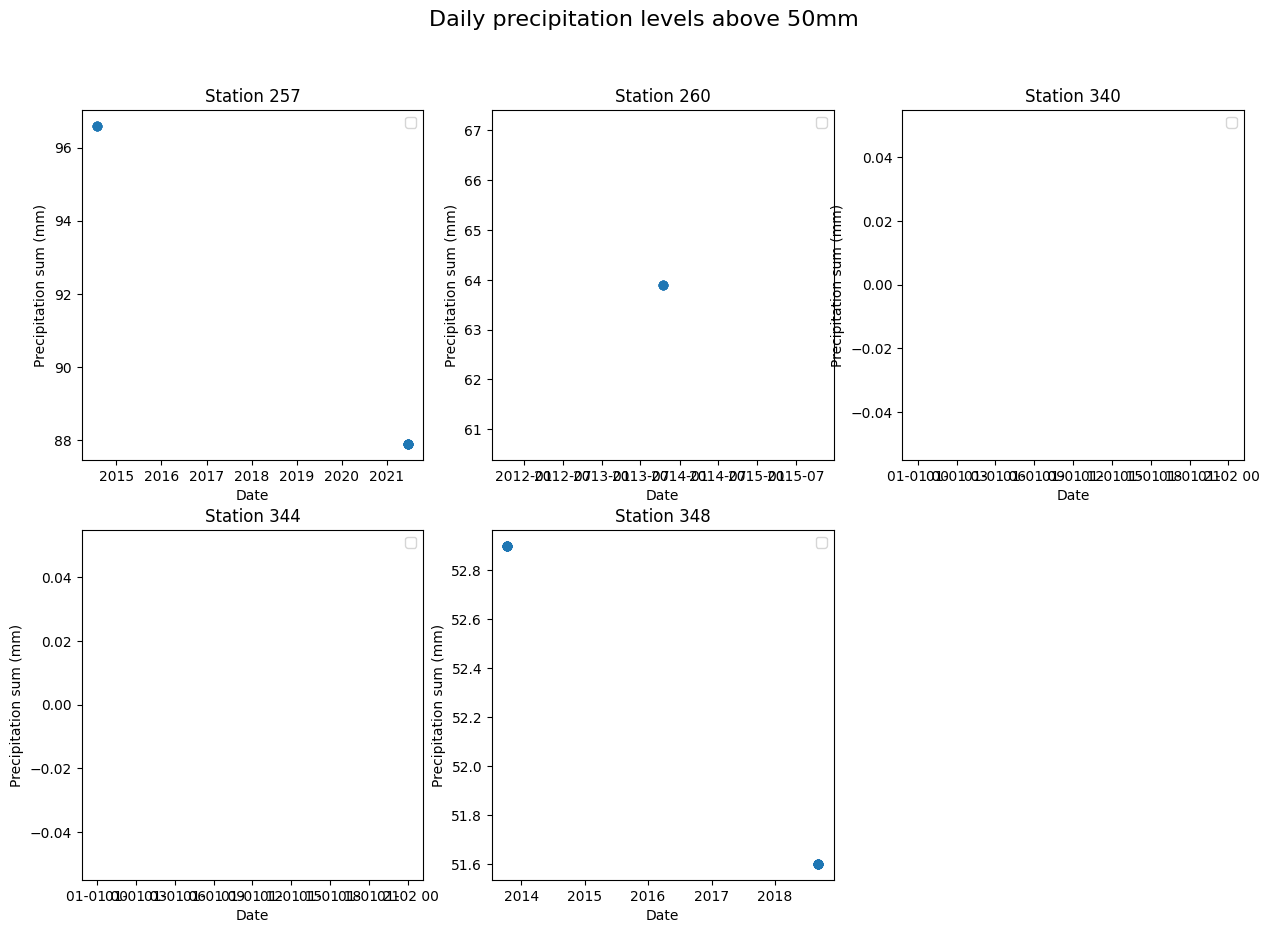

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot daily precipitation levels above 50mm for each station
n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[(filtered_data["KNMI_station_id"] == station) & (filtered_data["RH"] >= 50)]

    axes[i].scatter(station_data["Date"], station_data["RH"])
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Precipitation sum (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Daily precipitation levels above 50mm across KNMI stations", fontsize=16)

plt.show()
plt.tight_layout()

<Axes: title={'center': 'Average Monthly Precipitation Across Years'}, xlabel='Date'>

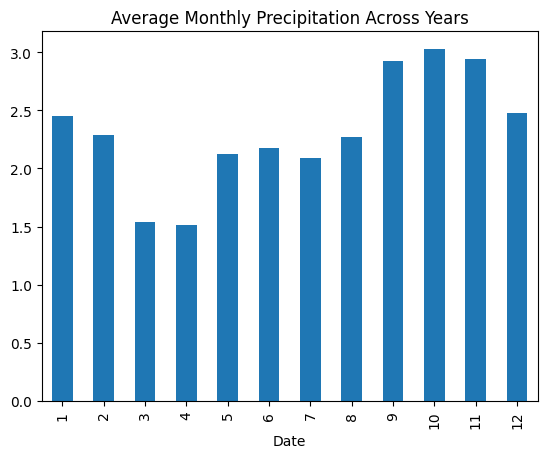

In [60]:
monthly_avg = filtered_data.groupby(filtered_data["Date"].dt.month)["RH"].mean()
monthly_avg.plot(kind="bar", title="Average Monthly Precipitation Across Years")

<Axes: title={'center': 'Annual Maximum Precipitation'}, xlabel='Date'>

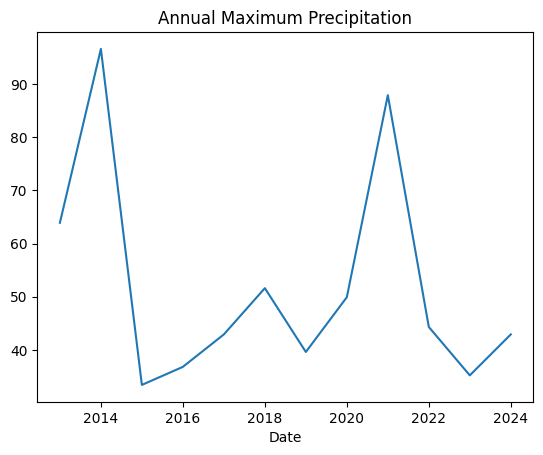

In [ ]:
# Do per station
annual_max = filtered_data.groupby(filtered_data["Date"].dt.year)["RH"].max()
annual_max.plot(title="Annual Maximum Precipitation")

<Axes: xlabel='RH', ylabel='Count'>

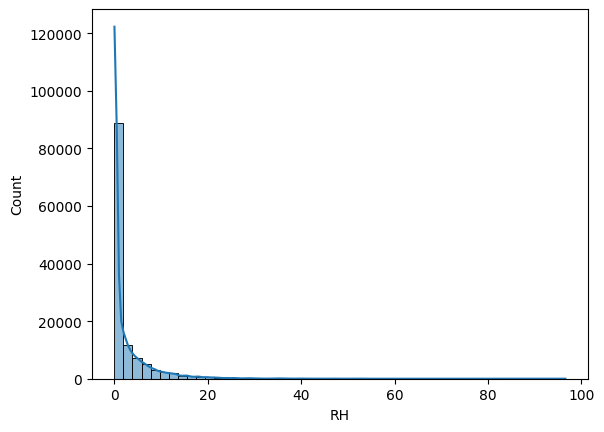

In [63]:
import seaborn as sns
sns.histplot(filtered_data["RH"], bins=50, kde=True)

### Analysis 2: 

In [4]:
# ...

### Analysis n:

In [5]:
# ...